In [27]:
import weaviate
from weaviate.classes.config import Configure, DataType, Multi2VecField, Property


In [28]:
client = weaviate.connect_to_local(
    host="172.17.0.5",  
    port=8080,
    grpc_port=50051,
 
)
print(client.is_ready())



True


In [29]:

client.collections.create(
    "DemoCollection",
    properties=[
        Property(name="title", data_type=DataType.TEXT),
        Property(name="poster", data_type=DataType.BLOB),
    ],
    vector_config=[
        Configure.Vectors.multi2vec_clip(
            name="title_vector",
            # Define the fields to be used for the vectorization - using image_fields, text_fields, video_fields
            image_fields=[
                Multi2VecField(name="poster", weight=0.9)
            ],
            text_fields=[
                Multi2VecField(name="title", weight=0.1)
            ]
        )
    ],
    # Additional parameters not shown
)

UnexpectedStatusCodeError: Collection may not have been created properly.! Unexpected status code: 422, with response body: {'error': [{'message': 'class name DemoCollection already exists'}]}.

In [30]:
def url_to_base64(url):
    import requests
    import base64

    image_response = requests.get(url)
    content = image_response.content
    return base64.b64encode(content).decode("utf-8")

In [33]:
import csv

with open("example.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    source_objects = list(reader)


In [34]:
collection = client.collections.use("DemoCollection")

with collection.batch.fixed_size(batch_size=200) as batch:
    for src_obj in source_objects:
        poster_b64 = url_to_base64(src_obj["poster_path"])
        weaviate_obj = {
            "title": src_obj["title"],
            "poster": poster_b64  # Add the image in base64 encoding
        }

        # The model provider integration will automatically vectorize the object
        batch.add_object(
            properties=weaviate_obj,
            # vector=vector  # Optionally provide a pre-obtained vector
        )

{'message': 'Failed to send 4 in a batch of 6', 'errors': {'fail with status 500: cannot identify image file <_io.BytesIO object at 0x79ffe678cc20>', 'fail with status 500: cannot identify image file <_io.BytesIO object at 0x79ffe678d670>', 'fail with status 500: cannot identify image file <_io.BytesIO object at 0x79ffe795db70>', 'fail with status 500: cannot identify image file <_io.BytesIO object at 0x79ffe61a98f0>'}}
{'message': 'Failed to send 4 objects in a batch of 6. Please inspect client.batch.failed_objects or collection.batch.failed_objects for the failed objects.'}


The Godfather


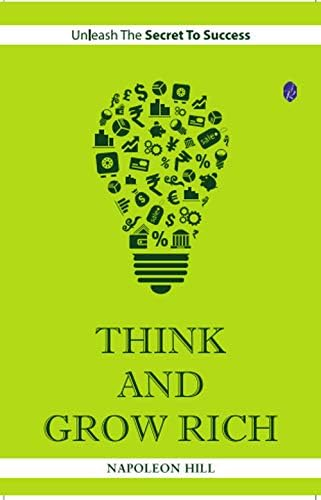

The Matrix


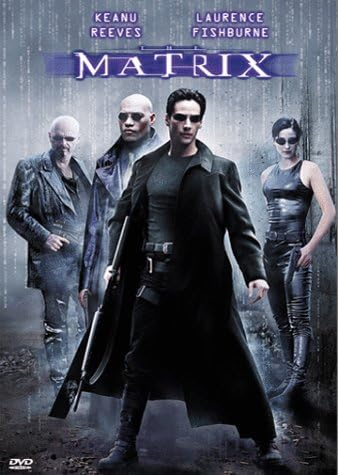

In [51]:
from PIL import Image
import io
import base64
collection = client.collections.use("DemoCollection")

response = collection.query.near_text(
    query="lightbulb",  # The model provider integration will automatically vectorize the query
    limit=2,
    return_properties=["title", "poster"]  # Optionally return specific properties
)

for obj in response.objects:
    print(obj.properties["title"])
    poster_b64 = obj.properties["poster"]
    poster_bytes = base64.b64decode(poster_b64)
    image = Image.open(io.BytesIO(poster_bytes))
    image.show()

